In [ ]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("/content/1_boston_housing.csv")

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
#Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [ ]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 613.7933 - mae: 22.8475 - val_loss: 545.6575 - val_mae: 21.7800
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 612.1416 - mae: 22.8350 - val_loss: 545.5309 - val_mae: 21.7839
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 610.4601 - mae: 22.8222 - val_loss: 545.4061 - val_mae: 21.7868
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 608.7889 - mae: 22.8075 - val_loss: 545.2548 - val_mae: 21.7886
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 607.3412 - mae: 22.7974 - val_loss: 545.1290 - val_mae: 21.7913
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 605.6927 - mae: 22.7824 - val_loss: 545.0021 - val_mae: 21.7932
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 604.1782 - mae: 22.7690 - val_loss: 544.8524 - val_mae: 21.7951
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 602.6440 - mae: 22.7557 - val_loss: 544.7157 - val_mae: 21.7966
Epoch 9/

In [ ]:
#Step 6: Build Deep Neural Network
model = Sequential()

# Single neuron → behaves like linear regression
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 627.9728 - mae: 22.9458 - val_loss: 570.3968 - val_mae: 22.1407
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 625.5667 - mae: 22.9254 - val_loss: 568.6096 - val_mae: 22.1249
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 623.0428 - mae: 22.9026 - val_loss: 566.9464 - val_mae: 22.1089
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 620.6946 - mae: 22.8798 - val_loss: 565.2901 - val_mae: 22.0922
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 618.3849 - mae: 22.8572 - val_loss: 563.6696 - val_mae: 22.0763
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 616.0780 - mae: 22.8362 - val_loss: 562.0768 - val_mae: 22.0599
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 613.8839 - mae: 22.8137 - val_loss: 560.5695 - val_mae: 22.0435
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 611.7666 - mae: 22.7932 - val_loss: 558.9770 - val_mae: 22.0275
Epoch 9/

In [ ]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 442.5593 - mae: 20.0358 
Test Loss (MSE): 442.5592956542969
Test MAE: 20.03575897216797


In [ ]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Actual: 23.60 | Predicted: 4.70
Actual: 32.40 | Predicted: 7.09
Actual: 13.60 | Predicted: -1.95
Actual: 22.80 | Predicted: 5.99
Actual: 16.10 | Predicted: -2.88


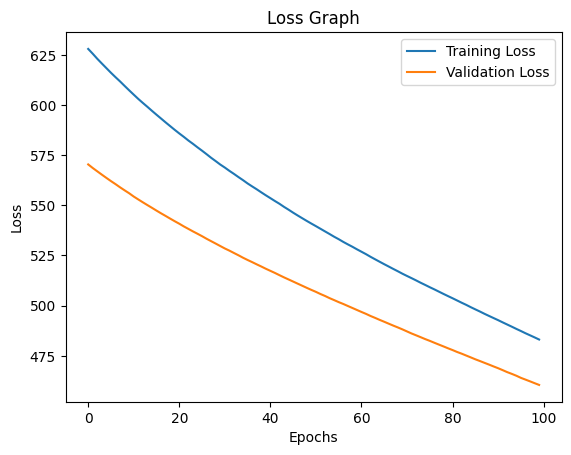

In [ ]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()